# Task 2: Multi-Modal Cardiac Image Fusion

**Goal:** Fuse a CT slice (excellent structural boundaries) and its matched
MRI slice (superior soft-tissue detail) of the same heart into a single
unified diagnostic view.

Pipeline: Load pair -> Histogram Equalization (independent) -> Color Mapping
-> Weighted Fusion (`cv2.addWeighted`) -> Log/Gamma safety transforms ->
Comparative Analysis.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)

def show(img, title):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


## 1. Load Modalities
Load one CT slice and its perfectly corresponding MRI slice.

CT shape: (400, 400) | MRI shape: (400, 400)


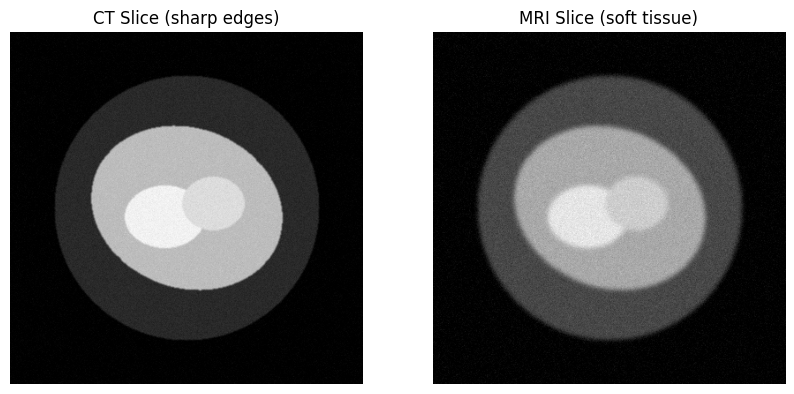

In [2]:
ct = cv2.imread('data/sample_ct.png', cv2.IMREAD_GRAYSCALE)
mri = cv2.imread('data/sample_mri.png', cv2.IMREAD_GRAYSCALE)

assert ct.shape == mri.shape, "CT and MRI slices must be spatially aligned / same shape"
print('CT shape:', ct.shape, '| MRI shape:', mri.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ct, cmap='gray'); ax[0].set_title('CT Slice (sharp edges)'); ax[0].axis('off')
ax[1].imshow(mri, cmap='gray'); ax[1].set_title('MRI Slice (soft tissue)'); ax[1].axis('off')
plt.show()


## 2. Histogram Equalization
Apply equalization to CT and MRI independently to maximize each modality's
dynamic range before blending.

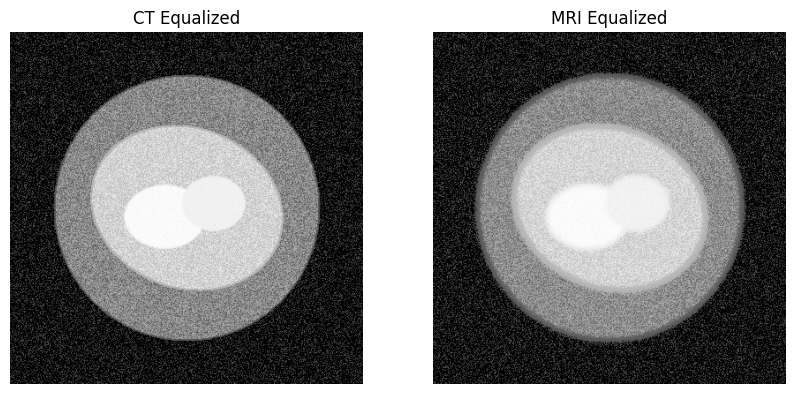

True

In [3]:
ct_eq = cv2.equalizeHist(ct)
mri_eq = cv2.equalizeHist(mri)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ct_eq, cmap='gray'); ax[0].set_title('CT Equalized'); ax[0].axis('off')
ax[1].imshow(mri_eq, cmap='gray'); ax[1].set_title('MRI Equalized'); ax[1].axis('off')
plt.show()
cv2.imwrite('output/01_ct_equalized.png', ct_eq)
cv2.imwrite('output/01_mri_equalized.png', mri_eq)


## 3. Color Mapping and Fusion (preview overlay)
Convert the enhanced CT and MRI into colored heatmaps using distinct
colormaps so structural (CT) vs soft-tissue (MRI) information stays visually
separable, then overlay them for a first look before weighted fusion.

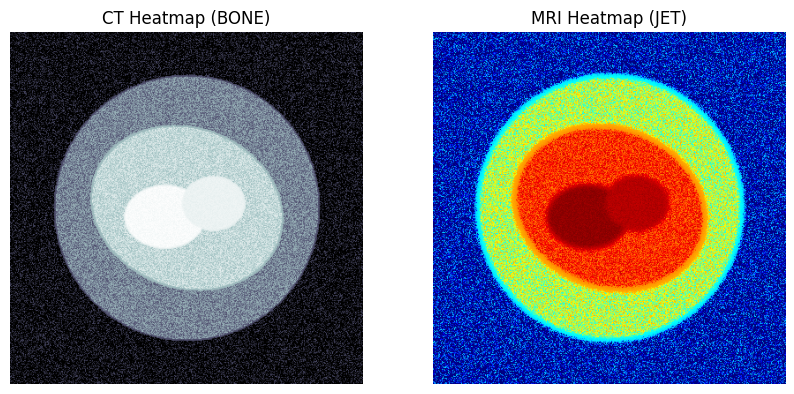

True

In [4]:
ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)   # structural: bone-like colormap
mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)   # soft tissue: JET highlights variation

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB)); ax[0].set_title('CT Heatmap (BONE)'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)); ax[1].set_title('MRI Heatmap (JET)'); ax[1].axis('off')
plt.show()
cv2.imwrite('output/02_ct_color.png', ct_color)
cv2.imwrite('output/02_mri_color.png', mri_color)


## 4. Multi-Modal Weighted Fusion
Use `cv2.addWeighted()` to blend the two colored matrices. A heavier weight
(alpha) is assigned to CT to preserve sharp anatomical edges, and a lighter
weight (beta) to MRI to layer in internal tissue variation.

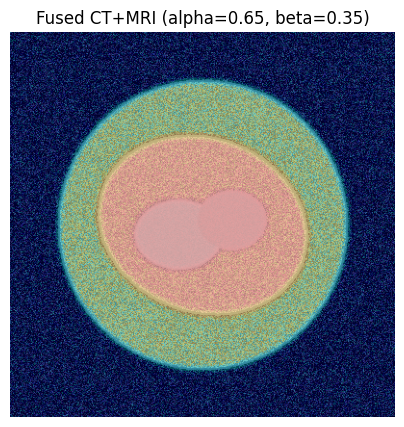

True

In [5]:
ALPHA = 0.65   # CT weight - preserves sharp anatomical boundaries
BETA = 0.35    # MRI weight - adds soft-tissue detail
GAMMA_OFFSET = 0

fused = cv2.addWeighted(ct_color, ALPHA, mri_color, BETA, GAMMA_OFFSET)
show(fused, f'Fused CT+MRI (alpha={ALPHA}, beta={BETA})')
cv2.imwrite('output/03_fused_raw.png', fused)


## 5. Logarithmic and Power-Law Safety Transforms
Pass the fused matrix through log and gamma functions so no critical data
gets crushed into pure black or blown out to pure white during the
weighted-addition step.

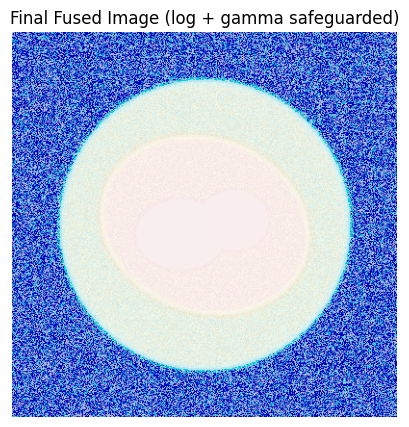

True

In [6]:
fused_f = fused.astype(np.float32)
c = 255 / np.log(1 + fused_f.max())
log_fused = c * np.log(1 + fused_f)
log_fused = np.clip(log_fused, 0, 255).astype(np.uint8)

GAMMA = 0.85
norm = log_fused.astype(np.float32) / 255.0
final_fused = np.power(norm, GAMMA) * 255.0
final_fused = np.clip(final_fused, 0, 255).astype(np.uint8)

show(final_fused, 'Final Fused Image (log + gamma safeguarded)')
cv2.imwrite('output/04_final_fused.png', final_fused)


## 6. Comparative Analysis
Display the standalone CT frame, the standalone MRI frame, and the fused
output side-by-side, plus intensity histograms, to validate the fusion.

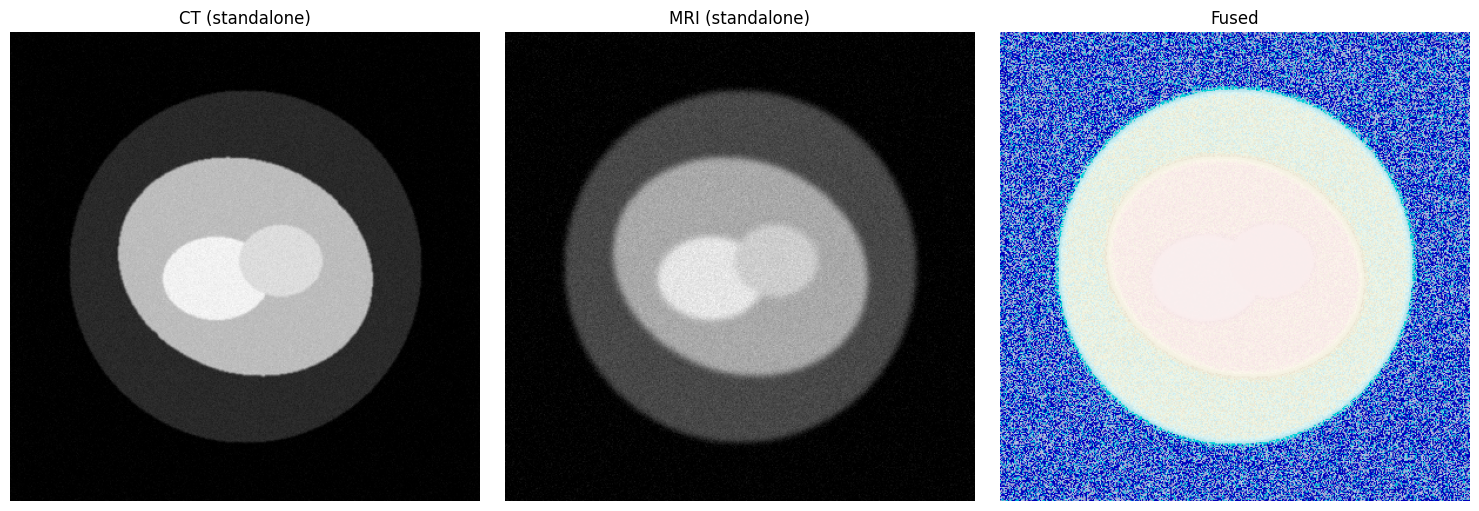

CT std: 72.18 | MRI std: 56.97 | Fused (gray) std: 85.56


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(ct, cmap='gray'); ax[0].set_title('CT (standalone)'); ax[0].axis('off')
ax[1].imshow(mri, cmap='gray'); ax[1].set_title('MRI (standalone)'); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(final_fused, cv2.COLOR_BGR2RGB)); ax[2].set_title('Fused'); ax[2].axis('off')
plt.tight_layout()
plt.savefig('output/05_side_by_side.png', dpi=150)
plt.show()

# Quick quantitative sanity check: fused image should carry the info range of both modalities
print('CT std:', ct.std().round(2), '| MRI std:', mri.std().round(2),
      '| Fused (gray) std:', cv2.cvtColor(final_fused, cv2.COLOR_BGR2GRAY).std().round(2))
